<a href="https://colab.research.google.com/github/anapbatista/BootCamp-EloGroup/blob/main/AED_BootCamp_Elo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atendimento



O atendimento pode estar concentrando sintomas de problemas recorrentes
O volume de tickets pode revelar padrões de atraso, produto, cobrança ou pós-venda — além de oportunidades de triagem e automação.

Investigue: quais temas mais se repetem, quais exigem prioridade e quais poderiam ser automatizados?

Objetivo: Mapear as causas-raiz dos tickets mais frequentes e estimar o ganho de produtividade/redução de custo com automação da triagem.

In [10]:
import pandas as pd

github_repo_path = 'anapbatista/BootCamp-EloGroup'
github_branch = 'main'
data_folder = 'data'

csv_file_name = 'atendimento.csv'


raw_github_url = f'https://raw.githubusercontent.com/{github_repo_path}/{github_branch}/{data_folder}/{csv_file_name}'

print(f'Tentando carregar CSV de: {raw_github_url}')


Tentando carregar CSV de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/atendimento.csv


In [11]:
# Carregar o CSV em um DataFrame do pandas
try:
    df = pd.read_csv(raw_github_url)
    print('CSV carregado com sucesso!')
    # Exibir as primeiras 5 linhas do DataFrame
    display(df.head())
except Exception as e:
    print(f'Erro ao carregar o CSV: {e}')
    print('Por favor, verifique se o URL do repositório, o nome do arquivo e o caminho da pasta estão corretos, e se o arquivo CSV existe e está acessível.')


CSV carregado com sucesso!


,ticket_id,customer_id,order_id,data_abertura,data_fechamento,canal_entrada,categoria_problema,status_atendimento,texto_cliente,nota_csat,tempo_primeira_resposta_minutos,custo_operacional_ticket
0,TKT-000001,CLI-01729,ORD-011396,2024-03-01 15:15:14,2024-03-05 06:15:14,ChatBot,Onde está meu pedido?,Resolvido,Comprei semana passada e nada até agora. Péssimo.,1.0,1.0,2.0
1,TKT-000002,CLI-11830,ORD-000852,2025-11-24 13:45:41,2025-11-25 18:45:41,E-mail,Onde está meu pedido?,Resolvido,Meu rastreio não atualiza desde terça. Alguém ...,2.0,419.0,15.0
2,TKT-000003,CLI-09211,ORD-060218,2025-03-22 09:24:06,2025-03-25 15:24:06,Telefone,Troca de Tamanho,Resolvido,Como solicito a troca? O tamanho P está pequen...,5.0,14.0,15.0
3,TKT-000004,CLI-05057,ORD-037931,2024-11-13 18:36:12,2025-12-31 23:59:00,WhatsApp,Defeito,Aberto,O produto chegou com defeito de fabricação.,3.0,13.0,15.0
4,TKT-000005,CLI-02924,ORD-009359,2023-07-05 18:10:23,2025-12-31 23:59:00,E-mail,Defeito,Em Análise,Comprei e já veio com problema. Péssima qualid...,3.0,241.0,15.0


In [12]:
print('Informações gerais do DataFrame:')
df.info()

print('\nEstatísticas descritivas das colunas numéricas:')
display(df.describe())


Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35841 entries, 0 to 35840
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ticket_id                        35841 non-null  object 
 1   customer_id                      35840 non-null  object 
 2   order_id                         35840 non-null  object 
 3   data_abertura                    35840 non-null  object 
 4   data_fechamento                  35840 non-null  object 
 5   canal_entrada                    35840 non-null  object 
 6   categoria_problema               35840 non-null  object 
 7   status_atendimento               35840 non-null  object 
 8   texto_cliente                    35840 non-null  object 
 9   nota_csat                        35840 non-null  float64
 10  tempo_primeira_resposta_minutos  35840 non-null  float64
 11  custo_operacional_ticket         35840 non-null

,nota_csat,tempo_primeira_resposta_minutos,custo_operacional_ticket
count,35840.000000,35840.000000,35840.000000
mean,3.240737,135.411551,14.851004
std,1.096796,254.171939,10.360604
min,1.000000,0.000000,2.000000
25%,3.000000,3.000000,15.000000
50%,3.000000,11.000000,15.000000
75%,4.000000,189.000000,15.000000
max,5.000000,1440.000000,45.000000


As 10 categorias de atendimento mais frequentes:


,count
categoria_problema,
Onde está meu pedido?,10765
Defeito,6509
Troca de Tamanho,5360
Dúvida Técnica,5314
Pagamento não aprovado,4281
Elogio,3611


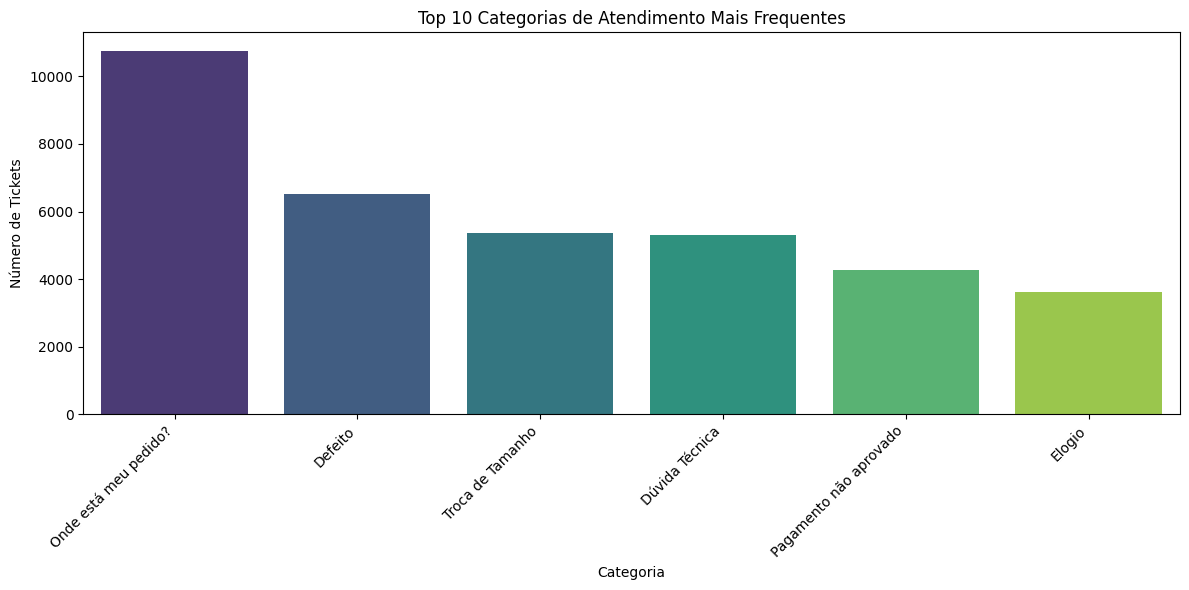

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Converter colunas de data para o tipo datetime para facilitar a análise posterior
df['data_abertura'] = pd.to_datetime(df['data_abertura'])
df['data_fechamento'] = pd.to_datetime(df['data_fechamento'])


print('As 10 categorias de atendimento mais frequentes:')
top_10_categorias = df['categoria_problema'].value_counts().head(10)
display(top_10_categorias)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_categorias.index, y=top_10_categorias.values, hue=top_10_categorias.index, palette='viridis', legend=False)
plt.title('Top 10 Categorias de Atendimento Mais Frequentes')
plt.xlabel('Categoria')
plt.ylabel('Número de Tickets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Investigando a Categoria Mais Frequente: 'Onde está meu pedido?'

Vamos focar na categoria de problema mais frequente para entender suas causas-raiz e identificar oportunidades de automação. Para isso, vamos filtrar os tickets relacionados a 'Onde está meu pedido?' e analisar o conteúdo do campo `texto_cliente`.

In [19]:
# Filtrar o DataFrame para a categoria 'Onde está meu pedido?'
tickets_pedido = df[df['categoria_problema'] == 'Onde está meu pedido?']

print(f"Número de tickets na categoria 'Onde está meu pedido?': {len(tickets_pedido)}")
print("\nExemplos de texto do cliente para 'Onde está meu pedido?':")

# Exibir uma amostra de 10 textos de clientes
for i, text in enumerate(tickets_pedido['texto_cliente'].sample(10, random_state=42)):
    print(f"- {text}")
    if i >= 9: # Limitar a 10 exemplos
        break

Número de tickets na categoria 'Onde está meu pedido?': 10765

Exemplos de texto do cliente para 'Onde está meu pedido?':
- Meu rastreio não atualiza desde terça. Alguém me ajuda?
- Comprei semana passada e nada até agora. Péssimo.
- Comprei semana passada e nada até agora. Péssimo.
- Meu rastreio não atualiza desde terça. Alguém me ajuda?
- Comprei semana passada e nada até agora. Péssimo.
- Cadê meu produto? Já passou da data prevista.
- Comprei semana passada e nada até agora. Péssimo.
- Fiz o pedido há 10 dias e ainda não chegou, o que está acontecendo?
- Fiz o pedido há 10 dias e ainda não chegou, o que está acontecendo?
- Comprei semana passada e nada até agora. Péssimo.


Análise de Texto para 'Onde está meu pedido?'

Vamos agora analisar o conteúdo da coluna `texto_cliente` para os tickets da categoria 'Onde está meu pedido?' para identificar palavras-chave e frases comuns. Isso nos ajudará a entender as causas-raiz e as oportunidades de automação.

In [22]:
from collections import Counter
import re
import nltk

# Baixar stopwords se ainda não tiver feito (executar apenas uma vez)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Função para pré-processar o texto
def preprocess_text(text):
    text = text.lower() # Converter para minúsculas
    text = re.sub(r'[^a-záéíóúâêôãõçà ]', '', text) # Remover caracteres especiais (mantendo acentos e espaços)
    text = re.sub(r' +', ' ', text).strip() # Remover múltiplos espaços
    return text

# Aplicar pré-processamento ao texto dos clientes
tickets_pedido.loc[:, 'texto_cliente_limpo'] = tickets_pedido['texto_cliente'].apply(preprocess_text) # Corrigido para usar .loc

# Juntar todos os textos limpos em uma única string
all_texts = ' '.join(tickets_pedido['texto_cliente_limpo'].tolist())

# Dividir a string em palavras e contar a frequência
words = all_texts.split()
word_counts = Counter(words)

print('As 20 palavras mais frequentes na categoria "Onde está meu pedido?":')
for word, count in word_counts.most_common(20):
    print(f'- {word}: {count}')

# Para uma análise mais aprofundada, podemos considerar N-grams (sequências de palavras)
# Vamos ver os bi-grams (pares de palavras)
from nltk.util import ngrams
from nltk.corpus import stopwords

stop_words = set(stopwords.words('portuguese'))

# Remover stopwords do texto limpo antes de gerar n-grams
filtered_words = [word for word in words if word not in stop_words and len(word) > 2]

bigrams = ngrams(filtered_words, 2)
bigram_counts = Counter(bigrams)

print('\nOs 20 bi-grams (pares de palavras) mais frequentes:')
for bigram, count in bigram_counts.most_common(20):
    print(f"- {' '.join(bigram)}: {count}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


As 20 palavras mais frequentes na categoria "Onde está meu pedido?":
- o: 6457
- não: 4431
- meu: 4396
- pedido: 4286
- e: 4254
- rastreio: 2260
- atualiza: 2260
- desde: 2260
- terça: 2260
- alguém: 2260
- me: 2260
- ajuda: 2260
- fiz: 2171
- há: 2171
- dias: 2171
- ainda: 2171
- chegou: 2171
- que: 2171
- está: 2171
- acontecendo: 2171

Os 20 bi-grams (pares de palavras) mais frequentes:
- rastreio atualiza: 2260
- atualiza desde: 2260
- desde terça: 2260
- terça alguém: 2260
- alguém ajuda: 2260
- fiz pedido: 2171
- pedido dias: 2171
- dias ainda: 2171
- ainda chegou: 2171
- chegou acontecendo: 2171
- cadê produto: 2136
- produto passou: 2136
- passou data: 2136
- data prevista: 2136
- pedido sumiu: 2115
- sumiu rastreamento: 2115
- rastreamento preciso: 2115
- preciso posição: 2115
- posição urgente: 2115
- comprei semana: 2083


## Resultados

- **Rastreamento Desatualizado/Inativo:** Palavras como 'rastreio', 'atualiza', 'desde', 'terça' e bi-grams como 'rastreio atualiza', 'atualiza desde', 'desde terça', 'alguém ajuda' indicam que muitos clientes estão reclamando que o status de rastreamento não é atualizado, gerando ansiedade e a necessidade de ajuda.
- **Atraso na Entrega/Não Recebimento:** Termos como 'pedido', 'dias', 'ainda', 'chegou', 'acontecendo', 'cadê produto', 'passou data', 'data prevista' e bi-grams como 'fiz pedido', 'pedido dias', 'ainda chegou', 'chegou acontecendo', 'cadê produto', 'passou data', 'data prevista' mostram que muitos pedidos estão atrasando ou não chegando na data esperada.
- **Pedido Perdido/Rastreamento Ineficaz:** Bi-grams como 'pedido sumiu', 'sumiu rastreamento', 'rastreamento preciso', 'preciso posição', 'posição urgente' sugerem que alguns pedidos podem estar realmente perdidos ou que o rastreamento é tão ineficaz que o cliente sente que o pedido 'sumiu', exigindo uma posição urgente.

## Priorização e Oportunidades de Automação:

- **Prioridade:** Os tickets da sub-categoria 'Pedido Perdido/Rastreamento Ineficaz' provavelmente exigem maior prioridade e intervenção humana imediata, pois indicam falhas críticas na entrega e podem levar à perda do cliente.
- **Automação Potencial:**
    - **Rastreamento Desatualizado/Inativo:** Um bot poderia ser implementado para, ao receber um ticket com frases como 'rastreio não atualiza', tentar obter a informação mais atualizada do sistema de logística e fornecer uma resposta instantânea ou um prazo para uma atualização. Se a atualização não resolver, escalar para um agente.
    - **Atraso na Entrega/Não Recebimento:** Para atrasos esperados ou dentro de uma janela de tolerância, um bot pode enviar comunicações proativas ou respostas automatizadas informando sobre o novo prazo de entrega, ou até mesmo iniciar um processo de reagendamento/compensação em casos mais severos. Para casos onde a data prevista já passou, o bot pode coletar o número do pedido e escalar para um agente com todas as informações pré-preenchidas.

# Clientes

O crescimento pode esconder diferenças importantes entre segmentos de clientes
Clientes com comportamento semelhante de compra podem apresentar margens, recorrência, ticket e custo de aquisição muito diferentes.

Investigue: quais perfis concentram valor, risco de churn ou potencial de retenção?

Objetivo: Segmentar a base de clientes e identificar quais segmentos devem receber ações de retenção, upsell ou redução de investimento.

In [24]:
github_repo_path = 'anapbatista/BootCamp-EloGroup'
github_branch = 'main'
data_folder = 'data'

csv_file_name = 'clientes.csv'


raw_github_url = f'https://raw.githubusercontent.com/{github_repo_path}/{github_branch}/{data_folder}/{csv_file_name}'

print(f'Tentando carregar CSV de: {raw_github_url}')


# Carregar o CSV em um DataFrame do pandas
try:
    df_cliente = pd.read_csv(raw_github_url)
    print('CSV carregado com sucesso!')
    # Exibir as primeiras 5 linhas do DataFrame
    display(df_cliente.head())
except Exception as e:
    print(f'Erro ao carregar o CSV: {e}')
    print('Por favor, verifique se o URL do repositório, o nome do arquivo e o caminho da pasta estão corretos, e se o arquivo CSV existe e está acessível.')



Tentando carregar CSV de: https://raw.githubusercontent.com/anapbatista/BootCamp-EloGroup/main/data/clientes.csv
CSV carregado com sucesso!


,customer_id,nome_completo,data_nascimento,genero,estado,cidade,nivel_fidelidade,data_cadastro,opt_in_newsletter,dispositivo_principal,renda_estimada,total_pedidos_historico,ltv_acumulado,segmento_rfm
0,CLI-00001,Thales Teixeira,1989-12-04,F,ES,Cariacica,Silver,2025-12-18,True,iOS,3097.06,7,3693.64,Fiel
1,CLI-00002,Allana Novais,2003-05-26,F,GO,Rio Verde,Bronze,2020-03-23,True,iOS,10577.04,7,2679.05,Churn
2,CLI-00003,Bryan da Rosa,2002-02-13,M,PB,João Pessoa,Bronze,2020-09-10,True,Android,7627.71,10,6954.27,Hibernando
3,CLI-00004,Sr. Davi Vieira,1997-05-15,M,MG,Uberlândia,Bronze,2025-06-06,True,Desktop,18905.35,6,2402.24,Em Risco
4,CLI-00005,Catarina Azevedo,2005-12-18,F,PE,Petrolina,Bronze,2021-11-11,True,Desktop,23045.56,1,256.93,Churn


In [25]:
print('Informações gerais do DataFrame de Clientes:')
df_cliente.info()

print('\nEstatísticas descritivas das colunas numéricas do DataFrame de Clientes:')
display(df_cliente.describe())

Informações gerais do DataFrame de Clientes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              15000 non-null  object 
 1   nome_completo            15000 non-null  object 
 2   data_nascimento          15000 non-null  object 
 3   genero                   15000 non-null  object 
 4   estado                   15000 non-null  object 
 5   cidade                   15000 non-null  object 
 6   nivel_fidelidade         15000 non-null  object 
 7   data_cadastro            15000 non-null  object 
 8   opt_in_newsletter        15000 non-null  bool   
 9   dispositivo_principal    15000 non-null  object 
 10  renda_estimada           15000 non-null  float64
 11  total_pedidos_historico  15000 non-null  int64  
 12  ltv_acumulado            15000 non-null  float64
 13  segmento_rfm             15000 

,renda_estimada,total_pedidos_historico,ltv_acumulado
count,15000.000000,15000.000000,15000.000000
mean,13783.378981,18.591200,9272.837923
std,6516.301869,21.605074,12151.621999
min,2502.620000,1.000000,133.550000
25%,8077.700000,5.000000,2128.327500
50%,13922.225000,9.000000,4773.165000
75%,19435.845000,25.000000,11479.685000
max,24997.710000,120.000000,118316.700000


Distribuição dos Segmentos RFM de Clientes:


,Contagem,Porcentagem (%)
segmento_rfm,,
Promissor,4127,27.51
Em Risco,3269,21.79
Fiel,2612,17.41
Hibernando,1928,12.85
Churn,1796,11.97
Campeão,1268,8.45


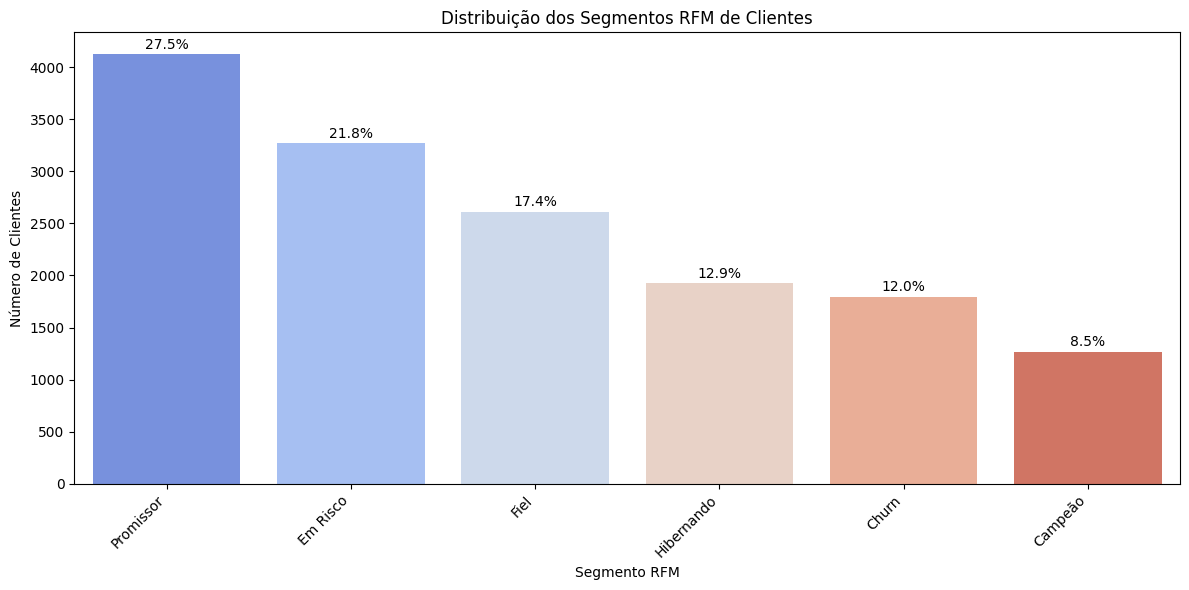

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Certifique-se que pandas está importado para DataFrame

# Converter colunas de data para o tipo datetime
df_cliente['data_nascimento'] = pd.to_datetime(df_cliente['data_nascimento'])
df_cliente['data_cadastro'] = pd.to_datetime(df_cliente['data_cadastro'])

print('Distribuição dos Segmentos RFM de Clientes:')
segmento_rfm_counts = df_cliente['segmento_rfm'].value_counts()
segmento_rfm_percent = df_cliente['segmento_rfm'].value_counts(normalize=True) * 100

# Criar um DataFrame para exibir contagem e porcentagem
segmento_rfm_df = pd.DataFrame({
    'Contagem': segmento_rfm_counts,
    'Porcentagem (%)': segmento_rfm_percent.round(2)
})
display(segmento_rfm_df)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=segmento_rfm_counts.index, y=segmento_rfm_counts.values, hue=segmento_rfm_counts.index, palette='coolwarm', legend=False)
plt.title('Distribuição dos Segmentos RFM de Clientes')
plt.xlabel('Segmento RFM')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45, ha='right')

# Adicionar rótulos de porcentagem nas barras
total = segmento_rfm_counts.sum()
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 50, # Ajustar a posição ligeiramente acima da barra
            '{:1.1f}%'.format(height/total*100),
            ha="center")

plt.tight_layout()
plt.show()

Média das Características Numéricas por Segmento RFM:


,renda_estimada,total_pedidos_historico,ltv_acumulado
segmento_rfm,,,
Campeão,13804.972957,54.010252,26670.755781
Fiel,13972.821853,34.248086,16896.754556
Promissor,13779.187155,15.979404,8077.970167
Em Risco,13713.558633,10.696849,5403.483197
Churn,13807.756008,5.417595,2782.084538
Hibernando,13617.173226,5.332988,2666.667184


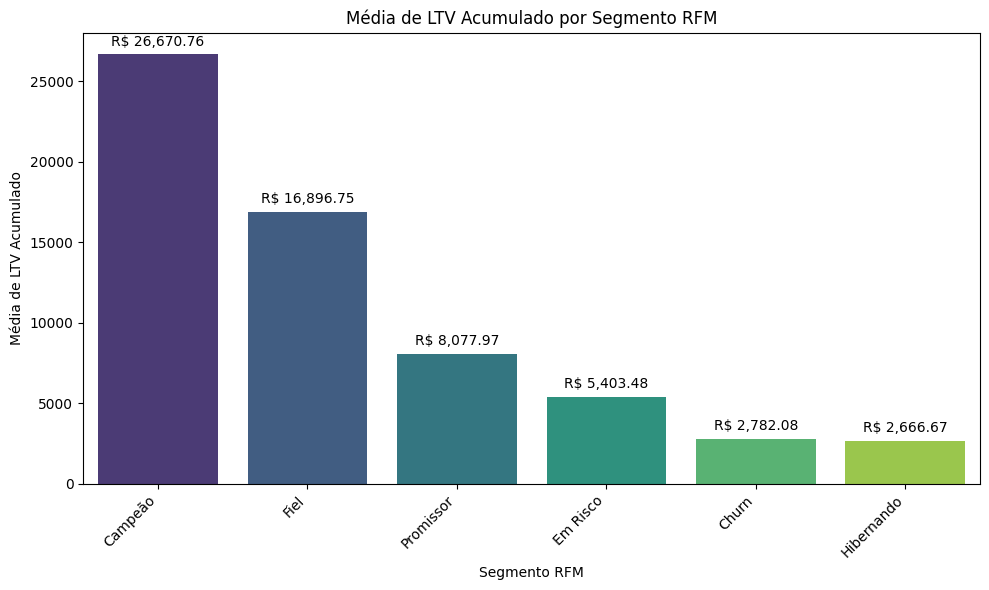

In [30]:
# Agrupar por segmento RFM e calcular a média das colunas numéricas
rfm_numerical_summary = df_cliente.groupby('segmento_rfm')[['renda_estimada', 'total_pedidos_historico', 'ltv_acumulado']].mean().sort_values(by='ltv_acumulado', ascending=False)

print('Média das Características Numéricas por Segmento RFM:')
display(rfm_numerical_summary)

# Visualizar a média de LTV Acumulado por Segmento
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=rfm_numerical_summary.index, y='ltv_acumulado', data=rfm_numerical_summary, hue=rfm_numerical_summary.index, palette='viridis', legend=False) # Corrigido: adicionado hue e legend=False
plt.title('Média de LTV Acumulado por Segmento RFM')
plt.xlabel('Segmento RFM')
plt.ylabel('Média de LTV Acumulado')
plt.xticks(rotation=45, ha='right')

# Adicionar rótulos de LTV nas barras
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + (rfm_numerical_summary['ltv_acumulado'].max() * 0.02), # Ajustar a posição ligeiramente acima da barra
            f'R$ {height:,.2f}', # Formatar como moeda
            ha="center")

plt.tight_layout()
plt.show()

Tempo Médio de Relacionamento (Anos) por Segmento RFM:


,Tempo Médio de Relacionamento (Anos)
segmento_rfm,
Hibernando,3.055197
Promissor,3.021527
Churn,3.002950
Fiel,2.983320
Campeão,2.964376
Em Risco,2.945078


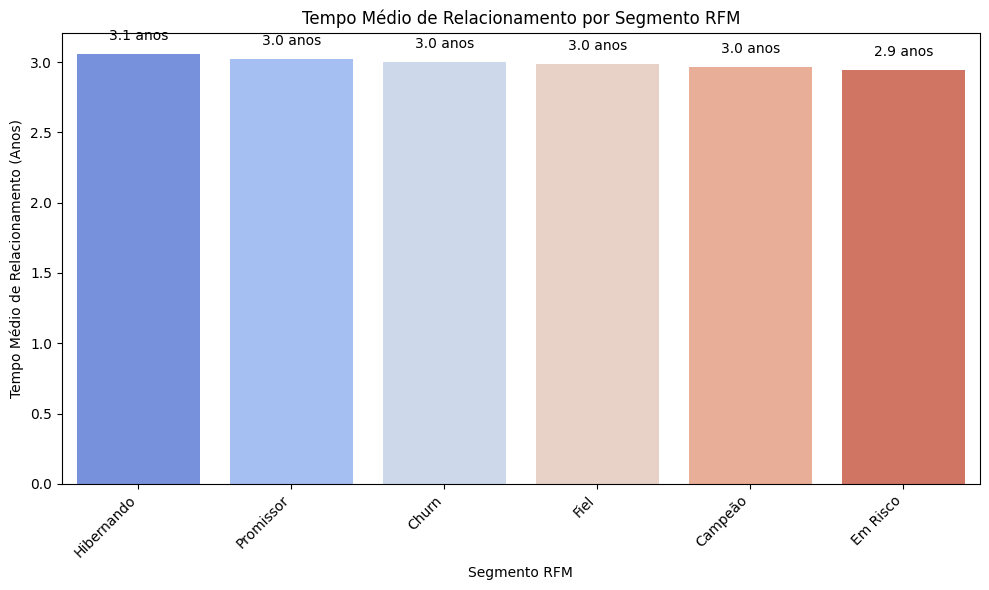

In [31]:
# Usar a data máxima de cadastro como referência para 'hoje' dentro do contexto do dataset,
# ou a data atual se for para o relacionamento contínuo.
# Para fins de análise, usaremos a data mais recente no dataset de cadastro.
# Alternativamente, pd.to_datetime('today') pode ser usado para o tempo de relacionamento real.

data_referencia = df_cliente['data_cadastro'].max() # Ou pd.to_datetime('today')

# Calcular o tempo de relacionamento em dias
df_cliente['tempo_relacionamento_dias'] = (data_referencia - df_cliente['data_cadastro']).dt.days

# Converter para anos para melhor legibilidade
df_cliente['tempo_relacionamento_anos'] = df_cliente['tempo_relacionamento_dias'] / 365.25

# Agrupar por segmento RFM e calcular o tempo médio de relacionamento
rfm_relacionamento_medio = df_cliente.groupby('segmento_rfm')['tempo_relacionamento_anos'].mean().sort_values(ascending=False)

print('Tempo Médio de Relacionamento (Anos) por Segmento RFM:')
display(rfm_relacionamento_medio.to_frame(name='Tempo Médio de Relacionamento (Anos)'))

# Visualizar o tempo médio de relacionamento
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=rfm_relacionamento_medio.index, y=rfm_relacionamento_medio.values, hue=rfm_relacionamento_medio.index, palette='coolwarm', legend=False)
plt.title('Tempo Médio de Relacionamento por Segmento RFM')
plt.xlabel('Segmento RFM')
plt.ylabel('Tempo Médio de Relacionamento (Anos)')
plt.xticks(rotation=45, ha='right')

# Adicionar rótulos de valores nas barras
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 0.1, # Ajustar a posição ligeiramente acima da barra
            f'{height:.1f} anos',
            ha="center")

plt.tight_layout()
plt.show()

## Resultados

### Perfis que concentram VALOR (Potencial de Upsell/Fidelização):

*   **Campeão:** São os clientes de maior valor. Possuem o maior `ltv_acumulado` (cerca de R\$ 26.670) e o maior `total_pedidos_historico` (mais de 54 pedidos). Embora a `renda_estimada` seja similar aos outros segmentos, o comportamento de compra é excepcional. Estratégias para eles devem focar em programas de recompensas exclusivos, ofertas premium e incentivo a se tornarem embaixadores da marca.
*   **Fiel:** Com um `ltv_acumulado` de aproximadamente R\$ 16.900 e mais de 34 pedidos, esses clientes também são extremamente valiosos. A meta é mantê-los engajados e incentivá-los a se tornarem Campeões com ofertas personalizadas e reconhecimento.

### Perfis com RISCO de CHURN (Ações de Retenção):

*   **Em Risco:** Apresentam um LTV e número de pedidos significativamente menores que os fiéis e promissores. Isso, combinado com o fato de estarem 'em risco', indica que estão começando a se afastar. Necessitam de campanhas de reengajamento, ofertas para reativar compras e possivelmente pesquisas para entender a causa da diminuição da atividade.
*   **Churn:** Possuem um LTV e número de pedidos muito baixos. Já abandonaram a marca. Ações aqui podem ser mais agressivas (descontos significativos, ofertas de retorno) ou, dependendo do custo de aquisição/reativação, pode-se considerar a redução do investimento em marketing direto.

### Perfis com Potencial de RETENÇÃO/CRESCIMENTO (Upsell/Cross-sell):

*   **Promissor:** Com um LTV de cerca de R\$ 8.000 e 16 pedidos, são clientes que demonstram potencial. O foco deve ser em nutrição, cross-selling e upsell para movê-los para o segmento Fiel ou Campeão.
*   **Hibernando:** Têm um LTV e número de pedidos muito baixos, próximos aos clientes de Churn. A diferença é que eles podem ter sido ativos no passado, mas estão inativos há mais tempo. Estratégias de reativação são cruciais, talvez com ofertas mais atrativas que as dos clientes 'Em Risco'.

### Observações Chave:

*   **Renda Estimada:** É fundamental notar que a `renda_estimada` é bastante consistente entre todos os segmentos, o que sugere que o comportamento de compra (recência, frequência, valor monetário) é um discriminador muito mais forte do que a renda para a segmentação RFM neste conjunto de dados.
*   **Tempo de Relacionamento:** O tempo médio de relacionamento dos clientes é notavelmente similar em todos os segmentos RFM (cerca de 3 anos). Isso indica que a longevidade do cliente por si só não é o fator principal que determina o segmento RFM; em vez disso, é o *comportamento* do cliente dentro desse período que define sua classificação. Portanto, as estratégias devem focar em incentivar o engajamento e a compra ativa.